In [2]:
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import beta
import joblib
from joblib import Parallel, delayed
from sklearn.model_selection import GridSearchCV
import contextlib
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from pyfrechet.metric_spaces import Spheroid, angles_to_spheroid, sphere_to_spheroid, spheroid_to_sphere 
import matplotlib.pyplot as plt

import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#### This notebook shows the results of the experiments on the spheroid.

In [ ]:
# Functions
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

# For to create the grid for the sphere
def create_S2_grid(grid_size: int=200) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
# Create a mesh grid for the unit sphere
    u = np.linspace(0, np.pi, grid_size)
    v = np.linspace(0, 2 * np.pi, grid_size)
    u, v = np.meshgrid(u, v)

    x_sphere = np.sin(u) * np.cos(v)
    y_sphere = np.sin(u) * np.sin(v)
    z_sphere = np.cos(u)
    return x_sphere, y_sphere, z_sphere

def create_spheroid_grid(grid_size: int=200, a: float=1.0, c: float=1.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    This is the grid we use for the spheroid plot wireframes
    """
    # Create a mesh grid for the spheroid
    u = np.linspace(0, np.pi, 2*grid_size)
    v = np.linspace(0, 2 * np.pi, grid_size)
    u, v = np.meshgrid(u, v)

    # Convert to spheroid using angles_to_spheroid
    spheroid_points = angles_to_spheroid(
        np.stack([u.flatten(), v.flatten()], axis=-1), a=a, c=c
    )
    x_spheroid = spheroid_points[:, 0].reshape(u.shape)
    y_spheroid = spheroid_points[:, 1].reshape(u.shape)
    z_spheroid = spheroid_points[:, 2].reshape(u.shape)
    
    return x_spheroid, y_spheroid, z_spheroid

def create_spheroid_points(N_points: int, a: float=1.0, c: float=1.0) -> np.ndarray:
    """
    This is the grid we use to plot the prediction balls
    """
    # Create grid in angle space
    u = np.linspace(0, np.pi, int(np.sqrt(N_points)))
    v = np.linspace(0, 2 * np.pi, 2*int(np.sqrt(N_points)))
    u, v = np.meshgrid(u, v)
    angles = np.stack([u.flatten(), v.flatten()], axis=-1)
    
    # Convert angles to spheroid points
    return angles_to_spheroid(angles, a=a, c=c)

# Modified plot_OOB_balls function that samples directly on spheroid
def plot_OOB_balls(M, true_y, predictions, indices_to_plot, Dalpha, ax, a=1.0, c=1.0, 
                   color='deepskyblue', alpha=0.1, N_points=2000):
    """
    Plot OOB balls using direct spheroid sampling.
    """
    # Sample points directly on spheroid
    spheroid_points = create_spheroid_points(N_points, a=a, c=c)
    
    for index_to_plot in indices_to_plot:
        center = predictions[index_to_plot, :]
        # Compute distances from center to all points
        print('center', center)
        dists = M.d(spheroid_points, center)
        mask = dists <= Dalpha
        
        # Plot the points inside the ball
        ax.scatter3D(spheroid_points[mask,0], spheroid_points[mask,1], spheroid_points[mask,2],
                    color=color, alpha=alpha, s=2)
        
        # Plot the prediction and true value
        ax.scatter3D(center[0], center[1], center[2], marker='x', color='red', s=30, alpha=1)
        ax.scatter3D(true_y[index_to_plot, 0], true_y[index_to_plot, 1], true_y[index_to_plot, 2],
                    marker='o', s=30, alpha=1, color='blue')

# Modified plot_OOB_balls function for custom points
def spheroid_custom_centers_plot_OOB_balls(M, points, Dalpha, ax, a=1.0, c=1.0, 
                   colors=['green', 'blue'], alpha=0.1, N_points=2000):
    """
    Plot OOB balls using direct spheroid sampling.
    """
    # Sample points directly on spheroid
    spheroid_points = create_spheroid_points(N_points, a=a, c=c)
    
    for i, center in enumerate(points):
        # Compute distances from center to all points
        dists = M.d(spheroid_points, center)
        mask = dists <= Dalpha
        mask = mask.squeeze()
        
        # Plot the points inside the ball
        ax.scatter3D(spheroid_points[mask,0], spheroid_points[mask,1], spheroid_points[mask,2],
                    color=colors[i % len(colors)], alpha=alpha, s=2)
        
        # Plot the center point
        ax.scatter3D(center[0], center[1], center[2], 
                    marker='x', color='red', s=30, alpha=1)
        
# Modified plot_OOB_balls function for custom points
def sphere_custom_centers_plot_OOB_balls(M, points, Dalpha, ax, a=1.0, c=1.0, 
                   colors=['green', 'blue'], alpha=0.1, N_points=2000):
    """
    Plot OOB balls using direct spheroid sampling.
    """
    # Sample points directly on spheroid
    spheroid_points = create_spheroid_points(N_points, a=a, c=c)
    
    for i, center in enumerate(points):
        # Compute distances from center to all points
        dists = M.d(spheroid_points, center)
        mask = dists <= Dalpha
        mask = mask.squeeze()
        
        sphere_points = spheroid_to_sphere(spheroid_points[mask], a, c, R=1)
        
        # Plot the points inside the ball (in sphere coordinates)
        ax.scatter3D(sphere_points[:,0], sphere_points[:,1], sphere_points[:,2],
                    color='green', alpha=alpha, s=2)
        
        # Map prediction and true value back to sphere and plot
        center_sphere = spheroid_to_sphere(center.reshape(1,-1), a, c, R=1)
        
        ax.scatter3D(center_sphere[0,0], center_sphere[0,1], center_sphere[0,2], 
                    marker='x', color='red', s=30, alpha=1)
        ax.scatter3D(sphere_points[0,0], sphere_points[0,1], sphere_points[0,2],
                    marker='o', s=30, alpha=1, color='blue')
        

def canonical_lattice(n: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate a canonical lattice on the unit sphere.
    
    Parameters:
    - n: int, number of points to generate

    Returns:
    - sphere_points: array of shape (n, 3) with coordinates on sphere
    """
    goldenRatio = (1 + 5**0.5)/2
    i = np.arange(0, n)
    theta = 2 * np.pi * i / goldenRatio
    phi = np.arccos(1 - 2*(i+0.5)/n)
    x = np.cos(theta) * np.sin(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(phi)
    return np.vstack((x, y, z)).T

def sphere_area_pred_ball(M_spheroid, radius, ref_points, sphere_points=None, n_points=5000, n_jobs=2):
    """
    Estimate areas of prediction balls for multiple reference points after mapping to sphere.
    
    Parameters:
    - M_spheroid: Spheroid metric space
    - radius: float, radius of the balls
    - ref_points: array of shape (n_refs, 3), centers of balls on sphere
    - sphere_points: optional, precomputed lattice points on sphere
    - n_points: int, number of lattice points if sphere_points not provided
    - n_jobs: int, number of parallel jobs
    
    Returns:
    - areas: array of areas for each reference point
    """
    # Generate or use provided lattice points
    if sphere_points is None:
        sphere_points = canonical_lattice(n_points)
    
    # Map lattice points to spheroid (do this once)
    spheroid_points = sphere_to_spheroid(sphere_points, M_spheroid.a, M_spheroid.c)
    
    # Function to process one reference point
    def process_ref_point(ref_point):
        # Map reference point to spheroid
        ref_spheroid = sphere_to_spheroid(ref_point.reshape(-1,3), 
                                        M_spheroid.a, M_spheroid.c).squeeze()
        
        # Count points inside ball
        inside_ball = np.sum(M_spheroid.d(spheroid_points, ref_spheroid) < radius)
        
        # Calculate area
        return 4 * np.pi * inside_ball / len(sphere_points)
    
    # Process all reference points in parallel
    areas = Parallel(n_jobs=n_jobs)(
        delayed(process_ref_point)(ref_point) 
        for ref_point in ref_points
    )
    
    return np.array(areas)


np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])

In [4]:
import numpy as np
import os

# Initialize a dictionary to store the loaded data
data_dict = {}

for i in range(12, 24):  # Cycles 12 to 23 (inclusive)
    filename = os.path.join(os.getcwd(), "results", f"spheroid_results_cycle_{i}.npy")
    try:
        data = np.load(filename, allow_pickle=True)
        data_dict[i] = data  # Use cycle number as key
        print(f"Successfully loaded {filename}")
    except FileNotFoundError:
        print(f"File {filename} not found. Skipping...")

# Now you can access data by cycle number, e.g.:
cycle_18_data = data_dict[18].item()  # Raises KeyError if key doesn't exist

Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_12.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_13.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_14.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_15.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_16.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_17.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_18.npy
Successfully loaded /Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/sunspots/results/spheroid_results_cycle_19.npy
Successf

center [-0.22277183  0.39697473 -0.41368478]
center [ 0.2516306   0.4204441  -0.19908589]
center [0.35287408 0.30351959 0.3652711 ]
center [-0.16707989  0.46663605 -0.13168307]
center [-0.0936106   0.37826287 -0.6265916 ]


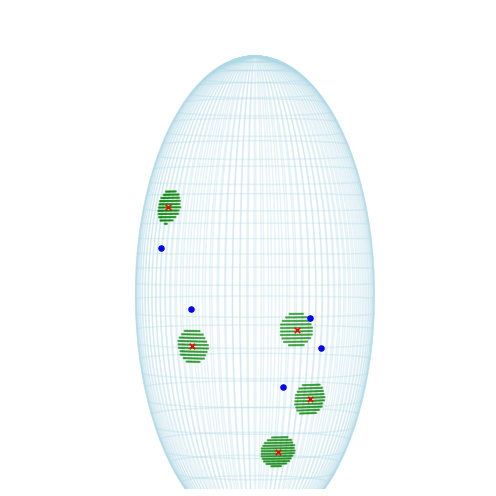

In [ ]:
# Load the test data and parameters
y_test = data_dict[18].item()['test_spheroid']
preds = data_dict[18].item()['preds_spheroid']
a = data_dict[18].item()['spheroid_best_params']['a']  # Get a parameter
c = data_dict[18].item()['spheroid_best_params']['c']  # Get c parameter

# Convert data to spheroid coordinates
y_test_spheroid = sphere_to_spheroid(y_test, a, c)
preds_spheroid = sphere_to_spheroid(preds, a, c)

fig = plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Create spheroid grid for wireframe
x_spheroid, y_spheroid, z_spheroid = create_spheroid_grid(grid_size=100, a=a, c=c)
ax.plot_wireframe(x_spheroid, y_spheroid, z_spheroid, color='lightblue', alpha=0.3, zorder=0)

indices = [7, 25, 28, 29, 32, 36, 37, 49, 50, 63, 94, 96]
new_indices = [idx for idx in indices if preds_spheroid[idx][1] >= 0]

# Create spheroid metric space
M_spheroid = Spheroid(a=a, c=c)

# Plot the balls
plot_OOB_balls(M=M_spheroid,
              true_y=y_test_spheroid,
              predictions=preds_spheroid,
              indices_to_plot=new_indices,
              Dalpha=data_dict[18].item()['oob_quantile_spheroid'][2],
              ax=ax,
              a=a,
              c=c,
              color='green',
              alpha=0.5,
              N_points=50000)

ax.view_init(elev=0, azim=90)
ax.set_xlim(-0.3*a, .3*a)
ax.set_ylim(0, a)
ax.set_zlim(-.5*c, 1.2*c)
Axes3D.set_aspect(ax, 'equal')
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()

plt.savefig('spheroid_prediction_balls.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

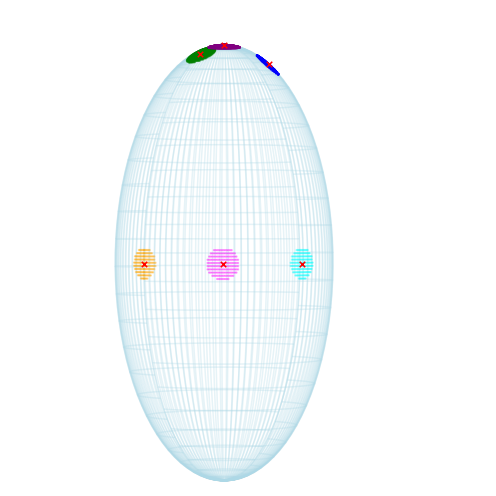

In [ ]:
# Load the parameters for the spheroid
a = 0.5
c = 1

fig = plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Create spheroid grid for wireframe
x_spheroid, y_spheroid, z_spheroid = create_spheroid_grid(grid_size=100, a=a, c=c)
ax.plot_wireframe(x_spheroid, y_spheroid, z_spheroid, color='lightblue', alpha=0.3, zorder=0)

# Points near pole on unit sphere (z ≈ 1)
# Points near pole on unit sphere (z ≈ 0.85 for more spread)
pole_points = np.array([
    [0.3, 0, 0.95],        # Further from center
    [-0.3, 0.3, 0.95],     # More separated in x-y plane
    [0, 0, 1]              # Exactly at pole
])

# Normalize to ensure they're on unit sphere
pole_points = pole_points / np.linalg.norm(pole_points, axis=1).reshape(-1, 1)

# Normalize to ensure they're on unit sphere
pole_points = pole_points / np.linalg.norm(pole_points, axis=1).reshape(-1, 1)

# Points near equator on unit sphere (z ≈ 0)
equator_points = np.array([
    [1, 0, 0],            # Point on x-axis
    [0, 1, 0],            # Point on y-axis
    [1/np.sqrt(2), 1/np.sqrt(2), 0]  # 45 degrees
])

# Map points to spheroid using sphere_to_spheroid
pole_points_spheroid = sphere_to_spheroid(pole_points, a=a, c=c)
equator_points_spheroid = sphere_to_spheroid(equator_points, a=a, c=c)

# Combine all points
test_points = np.vstack([pole_points_spheroid, equator_points_spheroid])

# Create spheroid metric space
M_spheroid = Spheroid(a=a, c=c)

# Plot the balls
spheroid_custom_centers_plot_OOB_balls(M=M_spheroid,
               points=test_points,
               Dalpha=data_dict[18].item()['oob_quantile_spheroid'][2],
               ax=ax,
               a=a,
               c=c,
               colors=['green', 'blue', 'purple', 'orange', 'cyan', 'magenta'],  # One color per point
               alpha=0.3,
               N_points=50000)

ax.view_init(elev=0, azim=45)
ax.set_xlim(-0.3*a, .3*a)
ax.set_ylim(0, 0.4)
ax.set_zlim(-1*c, 1.2*c)
Axes3D.set_aspect(ax, 'equal')
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()

plt.show()

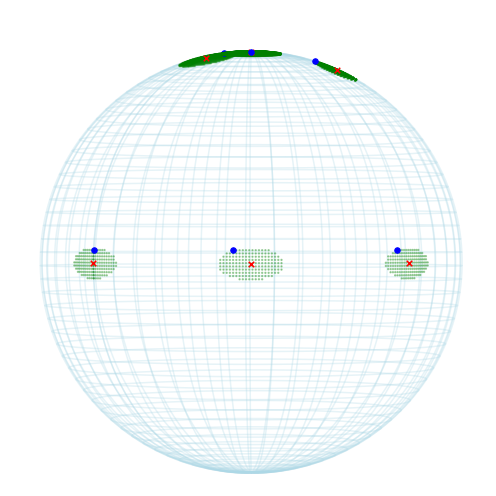

In [ ]:
# Load the parameters for the spheroid
a = 0.5
c = 1
# Points near pole on unit sphere (z ≈ 1)
# Points near pole on unit sphere (z ≈ 0.85 for more spread)
pole_points = np.array([
    [0.3, 0, 0.95],        # Further from center
    [-0.3, 0.3, 0.95],     # More separated in x-y plane
    [0, 0, 1]              # Exactly at pole
])

# Normalize to ensure they're on unit sphere
pole_points = pole_points / np.linalg.norm(pole_points, axis=1).reshape(-1, 1)

# Points near equator on unit sphere (z ≈ 0)
equator_points = np.array([
    [1, 0, 0],            # Point on x-axis
    [0, 1, 0],            # Point on y-axis
    [1/np.sqrt(2), 1/np.sqrt(2), 0]  # 45 degrees
])

# Map points to spheroid using sphere_to_spheroid
pole_points_spheroid = sphere_to_spheroid(pole_points, a=a, c=c)
equator_points_spheroid = sphere_to_spheroid(equator_points, a=a, c=c)

# Combine all points
preds_spheroid = np.vstack([pole_points_spheroid, equator_points_spheroid])

fig = plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Create sphere grid for wireframe (not spheroid)
x_sphere, y_sphere, z_sphere = create_S2_grid(grid_size=100)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder=0)

# Create spheroid metric space
M_spheroid = Spheroid(a=a, c=c)



# Plot the balls
sphere_custom_centers_plot_OOB_balls(M=M_spheroid,
               points=preds_spheroid,
               Dalpha=data_dict[18].item()['oob_quantile_spheroid'][2],
               ax=ax,
               a=a,
               c=c,
               colors=['green', 'blue', 'purple', 'orange', 'cyan', 'magenta'],  # One color per point
               alpha=0.3,
               N_points=50000)

ax.view_init(elev=0, azim=45)
ax.set_xlim(-0.4*a, .3*a)
ax.set_ylim(-0.4, 0.4)
ax.set_zlim(-1*c, 1.2*c)
Axes3D.set_aspect(ax, 'equal')
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()

plt.show()

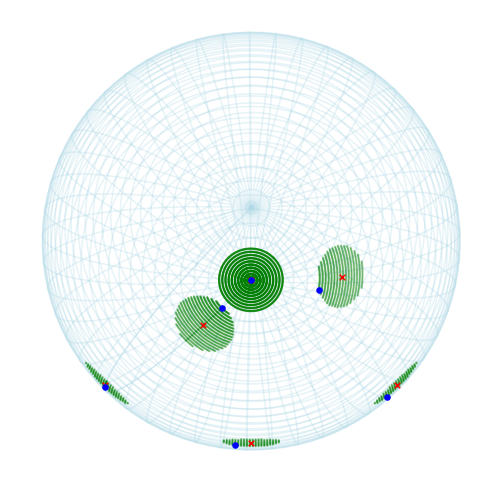

In [ ]:
# Load the parameters for the spheroid
a = 0.5
c = 1
# Points near pole on unit sphere (z ≈ 1)
# Points near pole on unit sphere (z ≈ 0.85 for more spread)
pole_points = np.array([
    [0.3, 0, 0.95],        # Further from center
    [-0.3, 0.3, 0.95],     # More separated in x-y plane
    [0, 0, 1]              # Exactly at pole
])

# Normalize to ensure they're on unit sphere
pole_points = pole_points / np.linalg.norm(pole_points, axis=1).reshape(-1, 1)

# Points near equator on unit sphere (z ≈ 0)
equator_points = np.array([
    [1, 0, 0],            # Point on x-axis
    [0, 1, 0],            # Point on y-axis
    [1/np.sqrt(2), 1/np.sqrt(2), 0]  # 45 degrees
])

# Map points to spheroid using sphere_to_spheroid
pole_points_spheroid = sphere_to_spheroid(pole_points, a=a, c=c)
equator_points_spheroid = sphere_to_spheroid(equator_points, a=a, c=c)

# Combine all points
preds_spheroid = np.vstack([pole_points_spheroid, equator_points_spheroid])

fig = plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Create sphere grid for wireframe (not spheroid)
x_sphere, y_sphere, z_sphere = create_S2_grid(grid_size=100)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder=0)

# Create spheroid metric space
M_spheroid = Spheroid(a=a, c=c)

# Modified plot_OOB_balls function for custom points
def sphere_custom_centers_plot_OOB_balls(M, points, Dalpha, ax, a=1.0, c=1.0, 
                   colors=['green', 'blue'], alpha=0.1, N_points=2000):
    """
    Plot OOB balls using direct spheroid sampling.
    """
    # Sample points directly on spheroid
    spheroid_points = create_spheroid_points(N_points, a=a, c=c)
    
    for i, center in enumerate(points):
        # Compute distances from center to all points
        dists = M.d(spheroid_points, center)
        mask = dists <= Dalpha
        mask = mask.squeeze()
        
        sphere_points = spheroid_to_sphere(spheroid_points[mask], a, c, R=1)
        
        # Plot the points inside the ball (in sphere coordinates)
        ax.scatter3D(sphere_points[:,0], sphere_points[:,1], sphere_points[:,2],
                    color='green', alpha=alpha, s=2)
        
        # Map prediction and true value back to sphere and plot
        center_sphere = spheroid_to_sphere(center.reshape(1,-1), a, c, R=1)
        
        ax.scatter3D(center_sphere[0,0], center_sphere[0,1], center_sphere[0,2], 
                    marker='x', color='red', s=30, alpha=1)
        ax.scatter3D(sphere_points[0,0], sphere_points[0,1], sphere_points[0,2],
                    marker='o', s=30, alpha=1, color='blue')

# Plot the balls
custom_centers_plot_OOB_balls(M=M_spheroid,
               points=preds_spheroid,
               Dalpha=data_dict[18].item()['oob_quantile_spheroid'][2],
               ax=ax,
               a=a,
               c=c,
               colors=['green', 'blue', 'purple', 'orange', 'cyan', 'magenta'],  # One color per point
               alpha=0.3,
               N_points=50000)

ax.view_init(elev=100, azim=45)
ax.set_xlim(-0.4*a, .3*a)
ax.set_ylim(-0.4, 0.4)
ax.set_zlim(-1*c, 1.2*c)
Axes3D.set_aspect(ax, 'equal')
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()

plt.show()

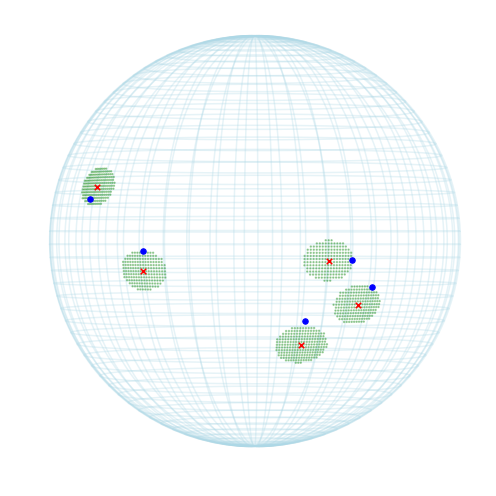

In [ ]:
# Load the test data and parameters
y_test = data_dict[18].item()['test_spheroid']
preds = data_dict[18].item()['preds_spheroid']
a = data_dict[18].item()['spheroid_best_params']['a']
c = data_dict[18].item()['spheroid_best_params']['c']

# Convert data to spheroid coordinates
y_test_spheroid = sphere_to_spheroid(y_test, a, c)
preds_spheroid = sphere_to_spheroid(preds, a, c)

fig = plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Create sphere grid for wireframe (not spheroid)
x_sphere, y_sphere, z_sphere = create_S2_grid(grid_size=100)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder=0)

indices = [7, 25, 28, 29, 32, 36, 37, 49, 50, 63, 94, 96]
new_indices = [idx for idx in indices if preds_spheroid[idx][1] >= 0]

# Create spheroid metric space
M_spheroid = Spheroid(a=a, c=c)

# Plot the balls
sphere_custom_centers_plot_OOB_balls(M=M_spheroid,
                     true_y=y_test_spheroid,
                     predictions=preds_spheroid,
                     indices_to_plot=new_indices,
                     Dalpha=data_dict[18].item()['oob_quantile_spheroid'][2],
                     ax=ax,
                     a=a,
                     c=c,
                     color='green',
                     alpha=0.3,
                     N_points=50000)

ax.view_init(elev=0, azim=90)
ax.set_xlim(-0.7, 0.7)
ax.set_ylim(-0.7, 0.7)
ax.set_zlim(-0.7, 0.7)
Axes3D.set_aspect(ax, 'equal')
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()

plt.show()

#### Show the results of area and coverage from the simulations

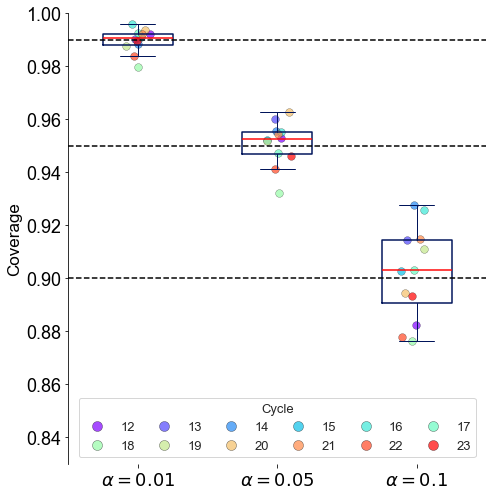

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import rainbow
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

reorder = lambda l, nc: sum((l[i::nc] for i in range(nc)), [])

np.random.seed(7)

# Custom styling for boxplots
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

# Set up data and colors
alphas = [0.1, 0.05, 0.01]
positions = [0, 1, 2]
cycle_range = list(range(12, 24))
num_cycles = len(cycle_range)

# Create a color map with one unique color per cycle
cycle_colors = ListedColormap(rainbow(np.linspace(0, 1, num_cycles)))

# Organize data: map alpha -> list of (cycle, value) pairs
pb_ii_cov_by_alpha = {alpha: [] for alpha in alphas}
for i, cycle in enumerate(cycle_range):
    result = data_dict.get(cycle).item()
    if result is None:
        continue
    coverages = result['pb_cov_spheroid']
    for alpha, cov in zip(alphas, coverages):
        pb_ii_cov_by_alpha[alpha].append((cycle, cov))

# Prepare data for boxplot
boxplot_data = [[val for _, val in pb_ii_cov_by_alpha[alpha]] for alpha in alphas]

# Plot
fig, ax = plt.subplots(figsize=(7, 7), facecolor="white")
sns.set_style("whitegrid")

# Boxplot
ax.boxplot(boxplot_data, positions=positions, widths=0.5, notch=False,
           boxprops=boxprops, whiskerprops=whiskerprops,
           capprops=capprops, showfliers=False,
           medianprops=medianprops, showmeans=False)

# Jittered scatter with color per cycle
for j, alpha in enumerate(alphas):
    for (cycle_idx, val) in pb_ii_cov_by_alpha[alpha]:
        color_idx = cycle_range.index(cycle_idx)
        x_jitter = np.random.normal(loc=positions[j], scale=0.05)
        ax.scatter(x_jitter, val, alpha=0.7,
                   color=cycle_colors(color_idx),
                   s=60, edgecolor='k', linewidth=0.3,
                   label=f'{cycle_idx}' if j == 0 else None)  # label only once per cycle

# Axis styling
xtick_labels = [r'$\alpha = 0.01$', r'$\alpha = 0.05$', r'$\alpha = 0.1$']
ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, fontsize=17)
ax.set_ylabel('Coverage', fontsize=17)
ax.tick_params(labelsize=18)
ax.axhline(y=1-0.01, color='black', linestyle='dashed')
ax.axhline(y=1-0.05, color='black', linestyle='dashed')
ax.axhline(y=1-0.1, color='black', linestyle='dashed')
ax.set_ylim(0.83, 1)
ax.grid(False)
sns.despine(bottom=True)

# Custom legend for cycles
legend_handles = [
    mlines.Line2D([], [], color=cycle_colors(i), marker='o', markeredgecolor='k', markeredgewidth=0.4, linestyle='none',
                  markersize=10, alpha = 0.7, label=f'{cycle_range[i]}')
    for i in range(num_cycles)
]

# Reorder legend handles for horizontal layout with 3 columns
ax.legend(handles=reorder(legend_handles, 6), title="Cycle", fontsize=13, title_fontsize=13,
          ncol=6, columnspacing = 1.25, loc='lower center')

fig.tight_layout()
#cplt.savefig("spheroid_sunspots_ii_cov.pdf", bbox_inches='tight', format='pdf', transparent=True)
plt.show()

Cambiar esto, el área ya vendrá dada

In [109]:
# Prepare data
alphas = [0.1, 0.05, 0.01]
positions = [0, 1, 2]
cycle_range = list(range(12, 24))
num_cycles = len(cycle_range)

# Initialize area_by_alpha dictionary
area_by_alpha = {alpha: [] for alpha in alphas}

can_lat = canonical_lattice(10000)
# Calculate areas for each cycle and alpha level
for cycle in cycle_range:
    result = data_dict.get(cycle).item()
    if result is None:
        continue
    
    # Get parameters for the spheroid
    a = result['spheroid_best_params']['a']
    c = result['spheroid_best_params']['c']
    M_spheroid = Spheroid(a=a, c=c)
    
    # Get oob_quantiles for this cycle
    oob_quantiles = result['oob_quantile_spheroid']
    
    # Calculate areas on sphere using modified area_pred_ball
    for alpha, radius in zip(alphas, oob_quantiles):
        area = sphere_area_pred_ball(M_spheroid, radius, ref_points= np.array([[np.sqrt(2)/2, np.sqrt(2)/2, 0], [np.sqrt(2)/2, np.sqrt(2)/2, 0]]), sphere_points=can_lat, n_jobs=1)
        area_by_alpha[alpha].append((cycle, area))

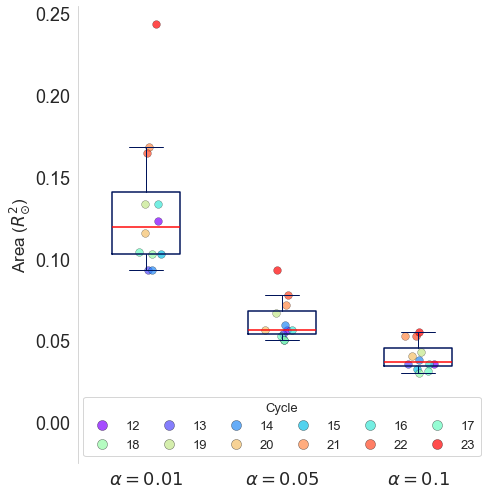

In [21]:
# Reuse style settings and helpers
reorder = lambda l, nc: sum((l[i::nc] for i in range(nc)), [])
np.random.seed(0)
# Prepare data
alphas = [0.1, 0.05, 0.01]
positions = [0, 1, 2]
cycle_range = list(range(12, 24))
num_cycles = len(cycle_range)

# Color map for cycles
cycle_colors = ListedColormap(rainbow(np.linspace(0, 1, num_cycles)))


# Format data for boxplot
boxplot_data = [[val for _, val in area_by_alpha[alpha]] for alpha in alphas]

# Plot
fig, ax = plt.subplots(figsize=(7, 7), facecolor="white")
sns.set_style("whitegrid")

# Boxplot
ax.boxplot(boxplot_data, positions=positions, widths=0.5, notch=False,
           boxprops=boxprops, whiskerprops=whiskerprops,
           capprops=capprops, showfliers=False,
           medianprops=medianprops, showmeans=False)

# Jittered scatter with color per cycle
for j, alpha in enumerate(alphas):
    for (cycle_idx, val) in area_by_alpha[alpha]:
        color_idx = cycle_range.index(cycle_idx)
        x_jitter = np.random.normal(loc=positions[j], scale=0.05)
        ax.scatter(x_jitter, val, alpha=0.7,
                   color=cycle_colors(color_idx),
                   s=60, edgecolor='k', linewidth=0.3,
                   label=f'{cycle_idx}' if j == 0 else None)

# Axis styling
xtick_labels = [r'$\alpha = 0.01$', r'$\alpha = 0.05$', r'$\alpha = 0.1$']
ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, fontsize=17)
ax.set_ylabel(r'Area ($R^2_{\odot}$)', fontsize=17)
ax.tick_params(labelsize=18)
ax.set_ylim(bottom=-0.025)  # optional: adjust based on your data
# ax.set_ylim(top=0.25)  # optional: adjust based on your data

ax.grid(False)
sns.despine(bottom=True)

# Custom legend
legend_handles = [
    mlines.Line2D([], [], color=cycle_colors(i), marker='o', linestyle='none', markeredgecolor='k', markeredgewidth=0.4, 
                  markersize=10, alpha=0.7, label=f'{cycle_range[i]}')
    for i in range(num_cycles)
]
ax.legend(handles=reorder(legend_handles, 6), title="Cycle", fontsize=13, title_fontsize=13,
          ncol=6, columnspacing=1.25, loc='lower center')

fig.tight_layout()
plt.savefig("spheroid_sunspots_area.pdf", bbox_inches='tight', format='pdf', transparent=True)
plt.show()

#### Generate table with MSE test, average area and average coverage

In [17]:
# read 'results/results_cycle_12.npy
with open('results/area_spheroid_all_results_cycle_23.npy', 'rb') as f:
    results = np.load(f, allow_pickle=True)
    
results

array([{'a': 0.2, 'c': 1, 'mean_area': 0.06282388285787553, 'test_point_areas': array([0.06283185, 0.06283185, 0.0578053 , 0.0678584 , 0.06031858,
              0.06031858, 0.06534513, 0.06283185, 0.06283185, 0.06534513,
              0.0779115 , 0.06031858, 0.06283185, 0.06283185, 0.06283185,
              0.0578053 , 0.06031858, 0.06534513, 0.06283185, 0.0678584 ,
              0.07037168, 0.0578053 , 0.0578053 , 0.0578053 , 0.06283185,
              0.06283185, 0.06283185, 0.06534513, 0.05277876, 0.06534513,
              0.06031858, 0.06534513, 0.06283185, 0.06031858, 0.06534513,
              0.06283185, 0.06031858, 0.06031858, 0.0678584 , 0.07037168,
              0.0578053 , 0.06534513, 0.06031858, 0.06031858, 0.06534513,
              0.0678584 , 0.06534513, 0.0678584 , 0.06283185, 0.0578053 ,
              0.06031858, 0.06283185, 0.06534513, 0.0578053 , 0.06283185,
              0.0578053 , 0.06283185, 0.06534513, 0.06031858, 0.06283185,
              0.0678584 , 0.0578053 , 0

In [77]:
def create_metrics_table(filepath):
    """
    Create a pandas DataFrame with metrics for different (a,c) configurations.
    
    Parameters:
    -----------
    filepath : str
        Path to the .npy file with results
        
    Returns:
    --------
    pd.DataFrame
        Table with MSE, average area and average coverage for each (a,c) pair
    """
    # Load results
    with open(filepath, 'rb') as f:
        results = np.load(f, allow_pickle=True)
    
    # Initialize lists to store data
    configs = []
    mse_values = []
    areas = []
    coverages = []
    
    # Extract metrics for each configuration
    for result in results:
        a = result['a']
        c = result['c']
        
        configs.append(f'({a:.1f},{c:.1f})')
        mse_values.append(1000*result['test_mse'])
        areas.append(100*result['mean_area'])
        print(result['type_II_coverage'])
        coverages.append(100*result['type_II_coverage'])
    
    # Create DataFrame
    df = pd.DataFrame({
        'MSE': mse_values,
        'PB area': areas,
        'Coverage': coverages
    }, index=configs)
    
    return df

def format_table_for_latex(df):
    """
    Format the metrics table for LaTeX.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Table with metrics
        
    Returns:
    --------
    str
        LaTeX code for the table
    """
    latex_code = df.to_latex(
        float_format=lambda x: '{:.2f}'.format(x),
        column_format='l|ccc',
        escape=False
    )
    
    # Add table header
    header = r"""\begin{table}[ht]
\centering
\caption{Metrics for different spheroid configurations (a,c)}
\label{tab:spheroid_metrics}
"""
    
    # Add table footer
    footer = r"\end{table}"
    
    return f"{header}{latex_code}{footer}"


# Create and display the table
filepath = 'results/area_spheroid_all_results_cycle_23.npy'
metrics_table = create_metrics_table(filepath)

# Sort by a values to match the specified order
metrics_table = metrics_table.reindex(['(0.2,1.0)', '(0.4,1.0)', '(0.6,1.0)', 
                                     '(0.8,1.0)', '(1.0,1.0)'])

print("\nDataFrame:")
print(metrics_table)

print("\nLaTeX code:")
print(format_table_for_latex(metrics_table))

0.8974630021141649
0.8985200845665962
0.8953488372093024
0.8921775898520085
0.8953488372093024

DataFrame:
                MSE   PB area   Coverage
(0.2,1.0)  9.428713  6.282388  89.746300
(0.4,1.0)  8.803939  4.799397  89.852008
(0.6,1.0)  8.637752  4.790630  89.534884
(0.8,1.0)  8.559494  5.292488  89.217759
(1.0,1.0)  8.598462  6.053377  89.534884

LaTeX code:
\begin{table}[ht]
\centering
\caption{Metrics for different spheroid configurations (a,c)}
\label{tab:spheroid_metrics}
\begin{tabular}{l|ccc}
\toprule
 & MSE & PB area & Coverage \\
\midrule
(0.2,1.0) & 9.43 & 6.28 & 89.75 \\
(0.4,1.0) & 8.80 & 4.80 & 89.85 \\
(0.6,1.0) & 8.64 & 4.79 & 89.53 \\
(0.8,1.0) & 8.56 & 5.29 & 89.22 \\
(1.0,1.0) & 8.60 & 6.05 & 89.53 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
def create_aggregated_metrics_table(base_path="results"):
    """
    Create aggregated metrics table with weighted averages across all cycles.
    
    Parameters:
    -----------
    base_path : str
        Base path where cycle result files are stored
        
    Returns:
    --------
    pd.DataFrame
        Table with weighted MSE, area and coverage for each (a,c) pair
    """
    # Initialize dictionaries to store aggregated values and weights
    total_samples = {}  # To store total samples per cycle
    aggregated_metrics = {
        '(0.2,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.4,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.6,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.8,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(1.0,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0}
    }
    
    # First pass: calculate total samples across all cycles
    total_samples_all_cycles = 0
    for cycle in range(12, 24):
        try:
            filepath = f"{base_path}/area_spheroid_all_results_cycle_{cycle}.npy"
            with open(filepath, 'rb') as f:
                results = np.load(f, allow_pickle=True)
                # Assuming all configurations have same number of samples per cycle
                n_samples = len(results[0]['test_point_areas'])
                total_samples[cycle] = n_samples
                total_samples_all_cycles += n_samples
        except FileNotFoundError:
            print(f"Warning: No file found for cycle {cycle}")
            continue
    
    # Second pass: calculate weighted metrics
    for cycle in range(12, 24):
        try:
            filepath = f"{base_path}/area_spheroid_all_results_cycle_{cycle}.npy"
            with open(filepath, 'rb') as f:
                results = np.load(f, allow_pickle=True)
                
            # Calculate weight for this cycle
            cycle_weight = total_samples[cycle] / total_samples_all_cycles
                
            # Process each configuration
            for result in results:
                config = f"({result['a']:.1f},{result['c']:.1f})"
                
                # Accumulate weighted metrics
                aggregated_metrics[config]['mse'] += cycle_weight * (1000 * result['test_mse'])
                aggregated_metrics[config]['area'] += cycle_weight * (100 * result['mean_area'])
                aggregated_metrics[config]['coverage'] += cycle_weight * (100 * result['type_II_coverage'])
                aggregated_metrics[config]['total_weight'] += cycle_weight
                
        except FileNotFoundError:
            continue
    
    # Create final DataFrame
    data = {
        'MSE': [],
        'PB area': [],
        'Coverage': []
    }
    configs = []
    
    for config in sorted(aggregated_metrics.keys()):
        configs.append(config)
        data['MSE'].append(aggregated_metrics[config]['mse'])
        data['PB area'].append(aggregated_metrics[config]['area'])
        data['Coverage'].append(aggregated_metrics[config]['coverage'])
    
    df = pd.DataFrame(data, index=configs)
    return df


Weighted Average Metrics Across All Cycles:
                MSE   PB area   Coverage
(0.2,1.0)  7.432434  5.964024  90.364078
(0.4,1.0)  6.696699  4.188109  90.218447
(0.6,1.0)  6.524535  4.116310  90.266990
(0.8,1.0)  6.457547  4.417201  90.266990
(1.0,1.0)  6.461299  4.824785  90.133495

LaTeX code:
\begin{table}[ht]
\centering
\caption{Metrics for different spheroid configurations (a,c)}
\label{tab:spheroid_metrics}
\begin{tabular}{l|ccc}
\toprule
 & MSE & PB area & Coverage \\
\midrule
(0.2,1.0) & 7.43 & 5.96 & 90.36 \\
(0.4,1.0) & 6.70 & 4.19 & 90.22 \\
(0.6,1.0) & 6.52 & 4.12 & 90.27 \\
(0.8,1.0) & 6.46 & 4.42 & 90.27 \\
(1.0,1.0) & 6.46 & 4.82 & 90.13 \\
\bottomrule
\end{tabular}
\end{table}


In [71]:
def create_aggregated_metrics_table(base_path="results"):
    """
    Create aggregated metrics table with weighted averages last three cycles.
    
    Parameters:
    -----------
    base_path : str
        Base path where cycle result files are stored
        
    Returns:
    --------
    pd.DataFrame
        Table with weighted MSE, area and coverage for each (a,c) pair
    """
    # Initialize dictionaries to store aggregated values and weights
    total_samples = {}  # To store total samples per cycle
    aggregated_metrics = {
        '(0.2,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.4,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.6,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(0.8,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0},
        '(1.0,1.0)': {'mse': 0, 'area': 0, 'coverage': 0, 'total_weight': 0}
    }
    
    # First pass: calculate total samples across last three cycles
    total_samples_all_cycles = 0
    for cycle in range(21, 24):
        try:
            filepath = f"{base_path}/area_spheroid_all_results_cycle_{cycle}.npy"
            with open(filepath, 'rb') as f:
                results = np.load(f, allow_pickle=True)
                # Assuming all configurations have same number of samples per cycle
                n_samples = len(results[0]['test_point_areas'])
                total_samples[cycle] = n_samples
                total_samples_all_cycles += n_samples
        except FileNotFoundError:
            print(f"Warning: No file found for cycle {cycle}")
            continue
    
    # Second pass: calculate weighted metrics
    for cycle in range(21, 24):
        try:
            filepath = f"{base_path}/area_spheroid_all_results_cycle_{cycle}.npy"
            with open(filepath, 'rb') as f:
                results = np.load(f, allow_pickle=True)
                
            # Calculate weight for this cycle
            cycle_weight = total_samples[cycle] / total_samples_all_cycles
                
            # Process each configuration
            for result in results:
                config = f"({result['a']:.1f},{result['c']:.1f})"
                
                # Accumulate weighted metrics
                aggregated_metrics[config]['mse'] += cycle_weight * (1000 * result['test_mse'])
                aggregated_metrics[config]['area'] += cycle_weight * (100 * result['mean_area'])
                aggregated_metrics[config]['coverage'] += cycle_weight * (100 * result['type_II_coverage'])
                aggregated_metrics[config]['total_weight'] += cycle_weight
                
        except FileNotFoundError:
            continue
    
    # Create final DataFrame
    data = {
        'MSE': [],
        'PB area': [],
        'Coverage': []
    }
    configs = []
    
    for config in sorted(aggregated_metrics.keys()):
        configs.append(config)
        data['MSE'].append(aggregated_metrics[config]['mse'])
        data['PB area'].append(aggregated_metrics[config]['area'])
        data['Coverage'].append(aggregated_metrics[config]['coverage'])
    
    df = pd.DataFrame(data, index=configs)
    return df

# Create and display the aggregated table
metrics_table = create_aggregated_metrics_table()

print("\nWeighted average metrics across last three cycles:")
print(metrics_table)

print("\nLaTeX code:")
print(format_table_for_latex(metrics_table))


Weighted average metrics across last three cycles:
                MSE   PB area   Coverage
(0.2,1.0)  9.405120  7.200498  90.032621
(0.4,1.0)  8.682845  5.202268  90.032621
(0.6,1.0)  8.577508  5.086579  89.851395
(0.8,1.0)  8.495596  5.489668  89.851395
(1.0,1.0)  8.528682  6.079136  89.452700

LaTeX code:
\begin{table}[ht]
\centering
\caption{Metrics for different spheroid configurations (a,c)}
\label{tab:spheroid_metrics}
\begin{tabular}{l|ccc}
\toprule
 & MSE & PB area & Coverage \\
\midrule
(0.2,1.0) & 9.41 & 7.20 & 90.03 \\
(0.4,1.0) & 8.68 & 5.20 & 90.03 \\
(0.6,1.0) & 8.58 & 5.09 & 89.85 \\
(0.8,1.0) & 8.50 & 5.49 & 89.85 \\
(1.0,1.0) & 8.53 & 6.08 & 89.45 \\
\bottomrule
\end{tabular}
\end{table}
